In [144]:
!pip install --upgrade imblearn

In [145]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [146]:
data=pd.read_csv('water_potability.csv')
data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [147]:
data.shape

(3276, 10)

In [148]:
(data.isnull().sum()/len(data))*100

,0
ph,14.987790
Hardness,0.000000
Solids,0.000000
Chloramines,0.000000
Sulfate,23.840049
Conductivity,0.000000
Organic_carbon,0.000000
Trihalomethanes,4.945055
Turbidity,0.000000
Potability,0.000000


In [149]:
data.duplicated().sum()

np.int64(0)

In [150]:
data.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [151]:

corr=data.corr(numeric_only=True)
corr

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.082096,-0.089288,-0.034350,0.018203,0.018614,0.043503,0.003354,-0.039057,-0.003556
Hardness,0.082096,1.000000,-0.046899,-0.030054,-0.106923,-0.023915,0.003610,-0.013013,-0.014449,-0.013837
Solids,-0.089288,-0.046899,1.000000,-0.070148,-0.171804,0.013831,0.010242,-0.009143,0.019546,0.033743
Chloramines,-0.034350,-0.030054,-0.070148,1.000000,0.027244,-0.020486,-0.012653,0.017084,0.002363,0.023779
Sulfate,0.018203,-0.106923,-0.171804,0.027244,1.000000,-0.016121,0.030831,-0.030274,-0.011187,-0.023577
Conductivity,0.018614,-0.023915,0.013831,-0.020486,-0.016121,1.000000,0.020966,0.001285,0.005798,-0.008128
Organic_carbon,0.043503,0.003610,0.010242,-0.012653,0.030831,0.020966,1.000000,-0.013274,-0.027308,-0.030001
Trihalomethanes,0.003354,-0.013013,-0.009143,0.017084,-0.030274,0.001285,-0.013274,1.000000,-0.022145,0.007130
Turbidity,-0.039057,-0.014449,0.019546,0.002363,-0.011187,0.005798,-0.027308,-0.022145,1.000000,0.001581
Potability,-0.003556,-0.013837,0.033743,0.023779,-0.023577,-0.008128,-0.030001,0.007130,0.001581,1.000000


<Axes: >

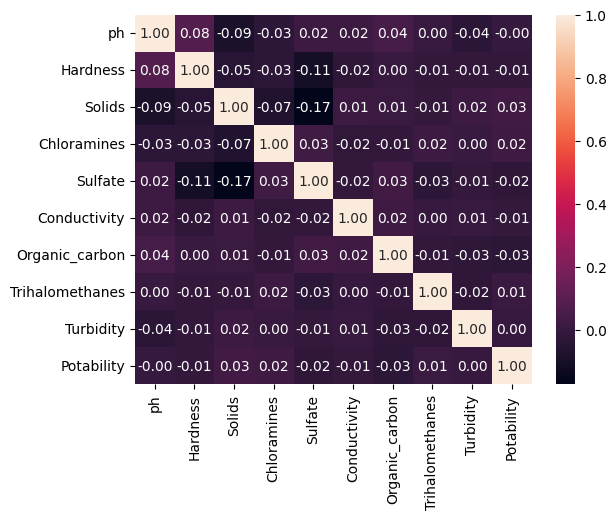

In [152]:
sns.heatmap(corr,annot=True,fmt='.2f')

# Univariate Analysis

In [153]:
num=data.columns
num

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

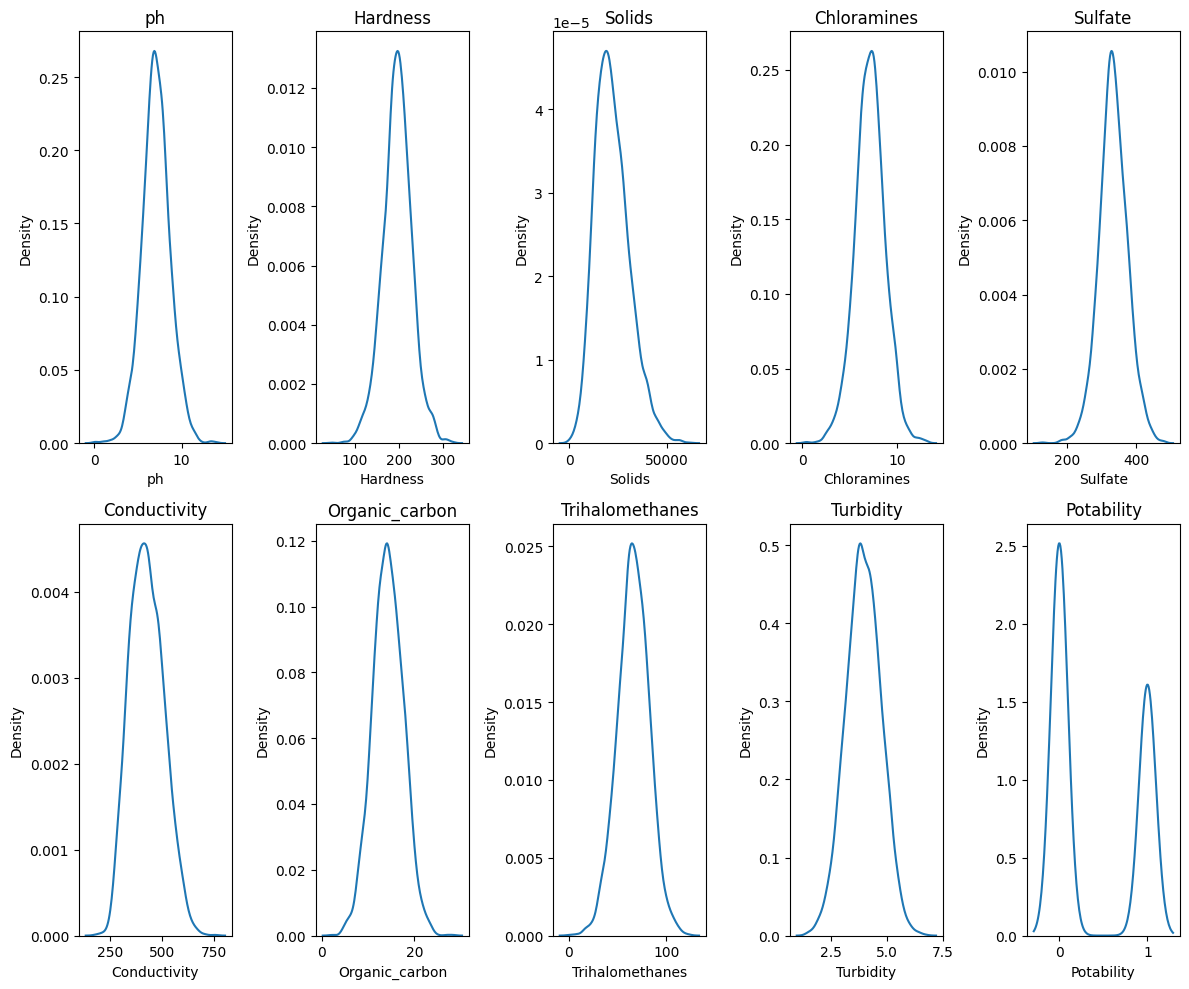

In [154]:
plt.figure(figsize=(12,10))
for index,col in enumerate(num):

  plt.subplot(2,5,index+1)
  sns.kdeplot(data[col])
  plt.title(col)
  plt.tight_layout()

In [155]:
for i in num:
  print(f'{i} : ',data[i].skew())

ph :  0.025630447632210205
Hardness :  -0.0393417047767249
Solids :  0.6216344855169127
Chloramines :  -0.01209844012438221
Sulfate :  -0.03594662160706187
Conductivity :  0.2644902239264119
Organic_carbon :  0.025532582090242492
Trihalomethanes :  -0.08303067407901553
Turbidity :  -0.007816642377392604
Potability :  0.4507837491078628


# Bivariate Analysis

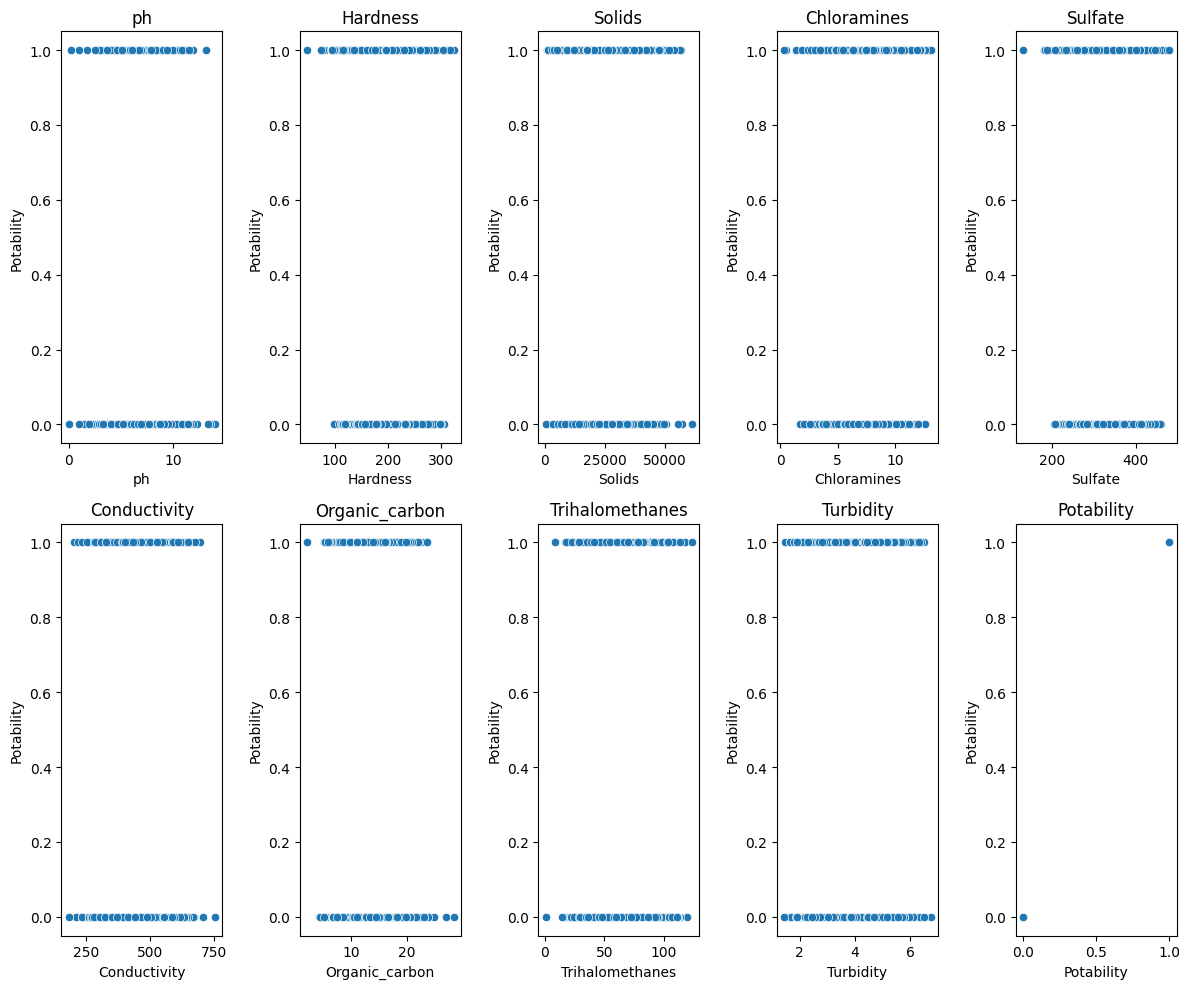

In [156]:
plt.figure(figsize=(12,10))
for index,col in enumerate(num):

  plt.subplot(2,5,index+1)
  sns.scatterplot(x=data[col],y=data['Potability'])
  plt.title(col)
  plt.tight_layout()

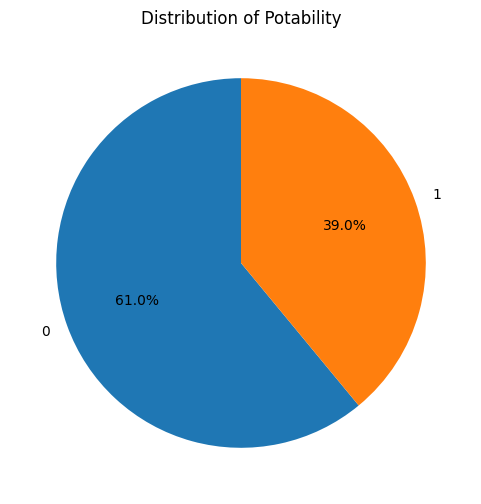

In [169]:
potability_counts = data['Potability'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(potability_counts, labels=potability_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Potability')
plt.ylabel('') # Hide the default 'y' label for pie charts
plt.show()

# As the data is imbalanced we use smote

#Visualing the outliers

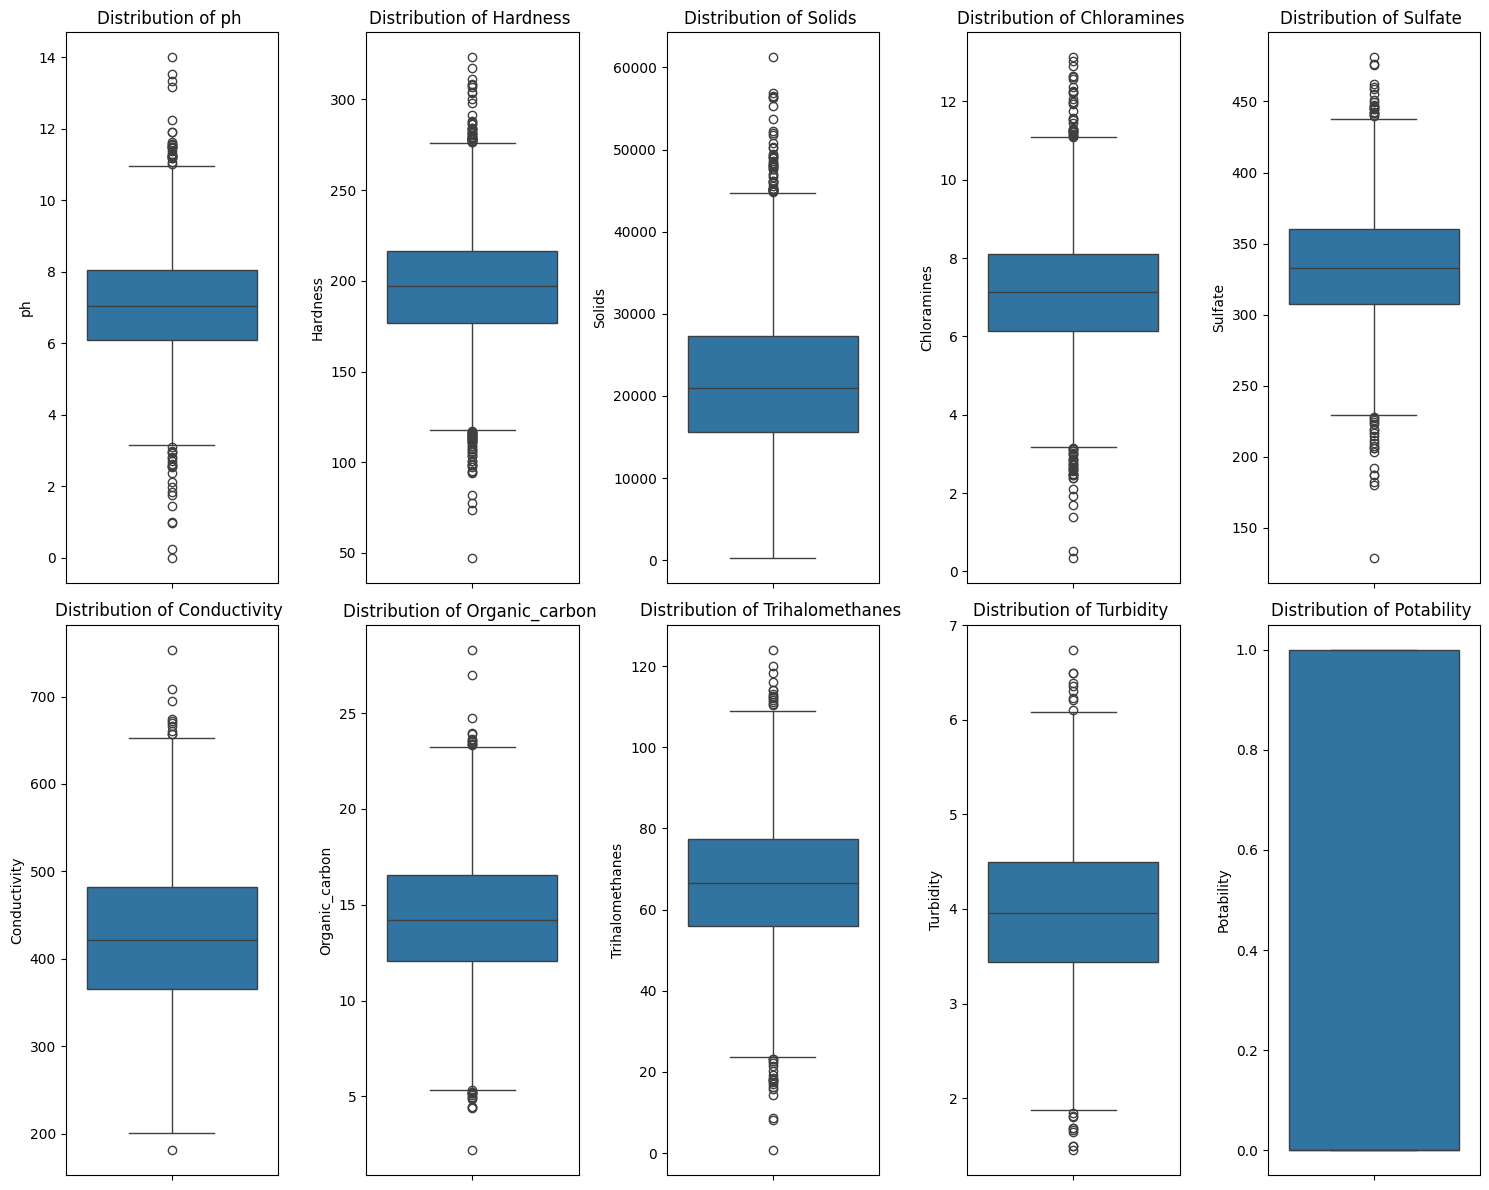

In [157]:


plt.figure(figsize=(15, 12))
for index, col in enumerate(num): # Plotting first 9 columns
  plt.subplot(2, 5, index + 1)
  sns.boxplot(y=data[col])
  plt.title(f'Distribution of {col} ')
  plt.tight_layout()
plt.show()

In [158]:
x=data.drop(columns=['Potability'])
y=data['Potability']

In [159]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

# Capping the outliers

In [160]:
def iqr_capping(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df



x_capped = x.copy()

for col in x_capped.columns:
    if x_capped[col].isnull().any():
        print(f"Skipping capping for {col} due to NaN values. Imputation should be done first.")
        continue
    x_capped = iqr_capping(x_capped, col)

print("Outliers capped for numerical features in x_capped.")
display(x_capped.describe())

Skipping capping for ph due to NaN values. Imputation should be done first.
Skipping capping for Sulfate due to NaN values. Imputation should be done first.
Skipping capping for Trihalomethanes due to NaN values. Imputation should be done first.
Outliers capped for numerical features in x_capped.


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000
mean,7.080795,196.392423,21957.112200,7.121794,333.775777,426.129974,14.283462,66.396293,3.966612
std,1.594320,32.017189,8592.820397,1.544126,41.416840,80.564144,3.288367,16.175008,0.776409
min,0.000000,117.125160,320.942611,3.146221,129.000000,191.647579,5.328026,0.738000,1.848797
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320
max,14.000000,276.392834,44831.869873,11.096086,481.030642,655.879140,23.295427,124.000000,6.091233


In [161]:
num=x.columns

In [162]:
numerical_impute_scale_features = ['ph', 'Sulfate', 'Trihalomethanes']
numerical_scale_only_features = [col for col in num if col not in numerical_impute_scale_features]

numeric_transformer_impute_scale = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_transformer_scale_only = Pipeline(steps=[
    ('scaler', StandardScaler())
])

trf = ColumnTransformer(
    transformers=[
        ('num_impute_scale', numeric_transformer_impute_scale, numerical_impute_scale_features),
        ('num_scale_only', numeric_transformer_scale_only, numerical_scale_only_features)
    ],
    remainder='drop' # Explicitly drop any unlisted columns, or use 'passthrough' if needed
)

### We first added pipeline as without it the imputed values were not being received by scaler and as a result was throwing error

In [163]:
model=[
('rf',RandomForestClassifier()),
('lr', LogisticRegression(random_state=42)),
('dt', DecisionTreeClassifier(random_state=42)),
('xg', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')),
('gb', GradientBoostingClassifier(random_state=42))
]

In [164]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report


In [165]:
results = {}

for name, estimator in model:
    print(f"\n--- Evaluating {name} ---")
    # Create a pipeline with the preprocessor and the current estimator
    full_pipeline = ImbPipeline(steps=[
        ('preprocessor', trf),
        ('smote',SMOTE(random_state=42)),
        ('classifier', estimator)
    ])

    # Fit the pipeline to the training data
    full_pipeline.fit(x_train, y_train)

    # Make predictions on the test set
    y_pred = full_pipeline.predict(x_test)
    y_pred_proba = full_pipeline.predict_proba(x_test)[:, 1] # Get probabilities for ROC AUC

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Store and print results
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc_score': roc_auc
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

print("\n--- Summary of Model Results ---")
for name, metrics in results.items():
    print(f"{name}: Accuracy={metrics['accuracy']:.4f}, ROC AUC={metrics['roc_auc_score']:.4f}")


--- Evaluating rf ---
Accuracy: 0.6524
Precision: 0.5364
Recall: 0.4836
F1-Score: 0.5086
ROC AUC Score: 0.6936
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.75      0.73       412
           1       0.54      0.48      0.51       244

    accuracy                           0.65       656
   macro avg       0.62      0.62      0.62       656
weighted avg       0.65      0.65      0.65       656


--- Evaluating lr ---
Accuracy: 0.4970
Precision: 0.3639
Recall: 0.4713
F1-Score: 0.4107
ROC AUC Score: 0.5069
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.51      0.56       412
           1       0.36      0.47      0.41       244

    accuracy                           0.50       656
   macro avg       0.49      0.49      0.49       656
weighted avg       0.53      0.50      0.51       656


--- Evaluating dt ---
Accuracy: 0.5686
Precision: 0.4296
Recall: 0.4877
F1-

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:21:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.6250
Precision: 0.4961
Recall: 0.5205
F1-Score: 0.5080
ROC AUC Score: 0.6654
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       412
           1       0.50      0.52      0.51       244

    accuracy                           0.62       656
   macro avg       0.60      0.60      0.60       656
weighted avg       0.63      0.62      0.63       656


--- Evaluating gb ---
Accuracy: 0.6098
Precision: 0.4769
Recall: 0.5082
F1-Score: 0.4921
ROC AUC Score: 0.6634
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.67      0.68       412
           1       0.48      0.51      0.49       244

    accuracy                           0.61       656
   macro avg       0.59      0.59      0.59       656
weighted avg       0.62      0.61      0.61       656


--- Summary of Model Results ---
rf: Accuracy=0.6524, ROC AUC=0.6936
lr: Accuracy=0.4970, ROC AUC=

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:22:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


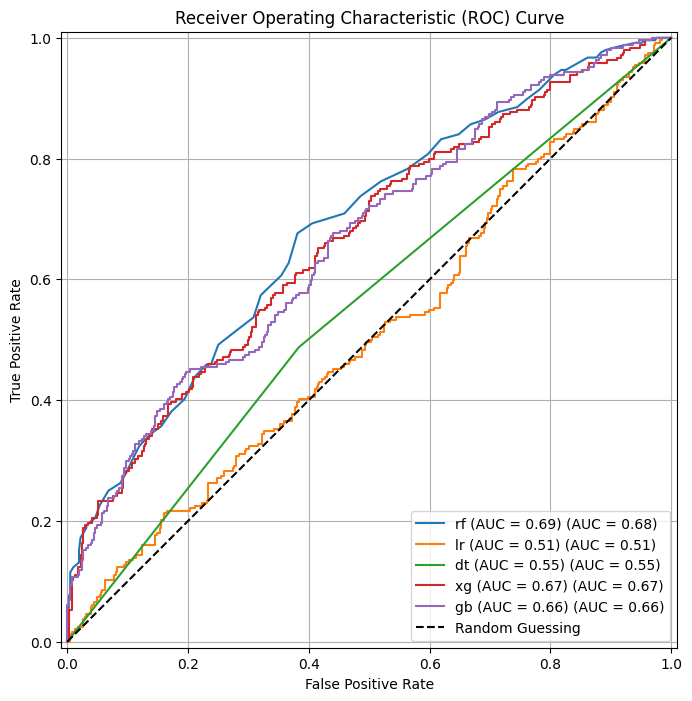

In [166]:
plt.figure(figsize=(10, 8))

fitted_pipelines = {}

for name, estimator in model:
    full_pipeline = ImbPipeline(steps=[
        ('preprocessor', trf),
        ('smote', SMOTE(random_state=42)),
        ('classifier', estimator)
    ])
    full_pipeline.fit(x_train, y_train)
    f_name = name + '_pipeline' # Use a distinct name for the fitted pipeline
    f_name = full_pipeline
    fitted_pipelines[name] = full_pipeline

    # Plot ROC curve for each model
    from sklearn.metrics import RocCurveDisplay
    RocCurveDisplay.from_estimator(full_pipeline, x_test, y_test, ax=plt.gca(), name=f'{name} (AUC = {results[name]["roc_auc_score"]:.2f})')

plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()